# Curriculum Learning — Red pequeña sin KD

Entrena la misma arquitectura del student (depthwise separable) usando Curriculum Learning
pero **sin Knowledge Distillation**. Sirve como baseline para comparar contra el student con KD.

- Mismo dataset split que `teacher.ipynb`
- Misma arquitectura que `student.ipynb`
- Mismas 6 fases cumulativas
- Sin teacher, sin soft labels

In [1]:
import os, sys
from pathlib import Path

_nvidia = Path(sys.executable).parent.parent / 'lib' / 'python3.12' / 'site-packages' / 'nvidia'
_paths  = [str(p) for p in _nvidia.glob('*/lib') if p.is_dir()]
_paths.append('/usr/lib/wsl/lib')
os.environ['LD_LIBRARY_PATH'] = ':'.join(_paths + [os.environ.get('LD_LIBRARY_PATH', '')])
print('LD_LIBRARY_PATH configurado')

LD_LIBRARY_PATH configurado


## 1. Imports y configuración

In [2]:
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

DATASET_DIR = Path('.')  # ejecutar desde Lab_3/Extra_1/
CLASS_NAMES = ['Ausente', 'Izquierda', 'Centro', 'Derecha']
NUM_CLASSES = 4
IMG_SIZE    = 128
BATCH_SIZE  = 32
SEED        = 42

print(f'Keras {keras.__version__}')
print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

I0000 00:00:1780367099.504259  524460 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780367099.550553  524460 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780367100.483744  524460 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras 3.14.1
TensorFlow 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carga y separación del dataset

Mismo split que `teacher.ipynb`:
- easy/medium: 0–80% train | 80–90% val | 90–100% test
- hard: 0–70% train | 70–85% val | 85–100% test
- other: 100% test

In [3]:
def load_subset(difficulty: str, frac_start: float, frac_end: float) -> tuple:
    d = DATASET_DIR / difficulty
    entries = []
    with open(d / 'tags.txt') as f:
        for line in f:
            line = line.strip()
            if line:
                fname, label = line.split(',')
                entries.append((d / fname, int(label)))
    rng = np.random.default_rng(seed=SEED)
    entries = [entries[i] for i in rng.permutation(len(entries))]
    n = len(entries)
    entries = entries[int(frac_start * n) : int(frac_end * n)]
    X = np.array([
        np.array(Image.open(p).convert('L'), dtype=np.float32)[..., np.newaxis] / 255.0
        for p, _ in entries
    ])
    y = np.array([lbl for _, lbl in entries], dtype=np.int32)
    return X, y

def concat_splits(specs):
    parts = [load_subset(d, s, e) for d, s, e in specs]
    return np.concatenate([p[0] for p in parts]), np.concatenate([p[1] for p in parts])

X_easy_raw, y_easy_raw = load_subset('easy',   0.00, 0.80)
X_med_raw,  y_med_raw  = load_subset('medium', 0.00, 0.80)
X_hard_raw, y_hard_raw = load_subset('hard',   0.00, 0.70)

X_val, y_val = concat_splits([
    ('easy',   0.80, 0.90),
    ('medium', 0.80, 0.90),
    ('hard',   0.70, 0.85),
])

X_easy_test,  y_easy_test  = load_subset('easy',   0.90, 1.00)
X_med_test,   y_med_test   = load_subset('medium', 0.90, 1.00)
X_hard_test,  y_hard_test  = load_subset('hard',   0.85, 1.00)
X_other_test, y_other_test = load_subset('other',  0.00, 1.00)

X_test = np.concatenate([X_easy_test, X_med_test, X_hard_test, X_other_test])
y_test = np.concatenate([y_easy_test, y_med_test, y_hard_test, y_other_test])

print(f'Train raw — easy: {len(X_easy_raw)}, medium: {len(X_med_raw)}, hard: {len(X_hard_raw)}')
print(f'Val: {len(X_val)}')
print(f'Test: {len(X_test)}  (easy={len(X_easy_test)}, medium={len(X_med_test)}, hard={len(X_hard_test)}, other={len(X_other_test)})')

Train raw — easy: 144, medium: 180, hard: 364
Val: 119
Test: 204  (easy=19, medium=23, hard=79, other=83)


## 3. Balance y fases del curriculum

In [4]:
def balance_dataset(X, y, target_per_class=180, seed=SEED):
    rng = np.random.default_rng(seed)
    X_out, y_out = [], []
    for c in range(NUM_CLASSES):
        mask = y == c
        X_c = X[mask]
        idx = rng.choice(len(X_c), target_per_class, replace=(len(X_c) < target_per_class))
        X_out.append(X_c[idx])
        y_out.append(np.full(target_per_class, c, dtype=np.int32))
    X_out, y_out = np.concatenate(X_out), np.concatenate(y_out)
    perm = rng.permutation(len(X_out))
    return X_out[perm], y_out[perm]

TARGET = 180
X_easy_b, y_easy_b = balance_dataset(X_easy_raw, y_easy_raw, target_per_class=TARGET)
X_med_b,  y_med_b  = balance_dataset(X_med_raw,  y_med_raw,  target_per_class=TARGET)
X_hard_b, y_hard_b = balance_dataset(X_hard_raw, y_hard_raw, target_per_class=TARGET)

n = TARGET * NUM_CLASSES  # 720

ph1_X, ph1_y = X_easy_b[:n//2],      y_easy_b[:n//2]
ph2_X, ph2_y = X_med_b[:int(n*.7)],  y_med_b[:int(n*.7)]
ph3_X, ph3_y = X_hard_b[:int(n*.3)], y_hard_b[:int(n*.3)]
ph4_X, ph4_y = X_easy_b[n//2:],      y_easy_b[n//2:]
ph5_X, ph5_y = X_med_b[int(n*.7):],  y_med_b[int(n*.7):]
ph6_X, ph6_y = X_hard_b[int(n*.3):], y_hard_b[int(n*.3):]

cum1_X, cum1_y = ph1_X, ph1_y
cum2_X = np.concatenate([cum1_X, ph2_X]); cum2_y = np.concatenate([cum1_y, ph2_y])
cum3_X = np.concatenate([cum2_X, ph3_X]); cum3_y = np.concatenate([cum2_y, ph3_y])
cum4_X = np.concatenate([cum3_X, ph4_X]); cum4_y = np.concatenate([cum3_y, ph4_y])
cum5_X = np.concatenate([cum4_X, ph5_X]); cum5_y = np.concatenate([cum4_y, ph5_y])
cum6_X = np.concatenate([cum5_X, ph6_X]); cum6_y = np.concatenate([cum5_y, ph6_y])

print(f'Balance: {TARGET}/clase = {n} imgs/dificultad')
for i, (X_p, y_p) in enumerate([
    (cum1_X,cum1_y),(cum2_X,cum2_y),(cum3_X,cum3_y),
    (cum4_X,cum4_y),(cum5_X,cum5_y),(cum6_X,cum6_y)], 1):
    print(f'  F{i}: {len(X_p):>5} imgs  ({len(X_p)//BATCH_SIZE} batches/epoch)')

Balance: 180/clase = 720 imgs/dificultad
  F1:   360 imgs  (11 batches/epoch)
  F2:   863 imgs  (26 batches/epoch)
  F3:  1079 imgs  (33 batches/epoch)
  F4:  1439 imgs  (44 batches/epoch)
  F5:  1656 imgs  (51 batches/epoch)
  F6:  2160 imgs  (67 batches/epoch)


## 4. Pipeline tf.data

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

@tf.function
def augment(x, y):
    crop = tf.random.uniform((), minval=int(0.82 * IMG_SIZE), maxval=IMG_SIZE, dtype=tf.int32)
    x = tf.image.random_crop(x, [crop, crop, 1])
    x = tf.image.resize(x, [IMG_SIZE, IMG_SIZE])
    x = tf.image.random_brightness(x, max_delta=0.15)
    x = tf.image.random_contrast(x, lower=0.75, upper=1.25)
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x, y

def make_ds(X, y, shuffle=False, aug=False):
    ds = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED)
    if aug:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds        = make_ds(X_val,        y_val)
test_ds       = make_ds(X_test,       y_test)
easy_test_ds  = make_ds(X_easy_test,  y_easy_test)
med_test_ds   = make_ds(X_med_test,   y_med_test)
hard_test_ds  = make_ds(X_hard_test,  y_hard_test)
other_test_ds = make_ds(X_other_test, y_other_test)

print('Datasets listos')

I0000 00:00:1780367105.791564  524460 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5298 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets listos


## 5. Arquitectura

Misma red que `student.ipynb`: depthwise separable convolutions.
Mantiene tamaño pequeño (~8.5 KB cuantizado) apto para ESP32-CAM.

In [6]:
def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    x = layers.Conv2D(32, 7, strides=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D()(x)

    x = layers.DepthwiseConv2D(3, strides=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 1, use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D()(x)

    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 1, use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='curriculum_model')

model = build_model()
model.summary()
print(f'\nParámetros: {model.count_params():,}')
print(f'Tamaño float32: ~{model.count_params() * 4 / 1024:.1f} KB')
print(f'Tamaño INT8 estimado: ~{model.count_params() / 1024:.1f} KB')

Model: "curriculum_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 43, 43, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 43, 43, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 21, 21, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 7, 7, 32)       │           288 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 3, 3, 64)       │           576 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           26

 Total params: 9,860 (38.52 KB)

 Trainable params: 9,348 (36.52 KB)

 Non-trainable params: 512 (2.00 KB)


Parámetros: 9,860
Tamaño float32: ~38.5 KB
Tamaño INT8 estimado: ~9.6 KB


## 6. Entrenamiento — Curriculum Learning (6 fases cumulativas)

- **LR se resetea** al inicio de cada fase: al agregar datos más difíciles, el modelo necesita
  capacidad de adaptación (más LR), no menos.
- **Checkpoint monitorea `val_loss`** (no `val_accuracy`): el val set es desbalanceado (46% ausente),
  por lo que val_accuracy=46% para "predice siempre ausente" se vería mejor que un modelo que aprende.
- **ReduceLROnPlateau** reduce el LR dentro de cada fase si el val_loss no mejora.

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

rlr  = keras.callbacks.ReduceLROnPlateau(
    factor=0.5, patience=10, min_lr=1e-6, monitor='val_loss', verbose=1)
ckpt = keras.callbacks.ModelCheckpoint(
    'curriculum_best.weights.h5', save_best_only=True,
    monitor='val_loss', mode='min', verbose=1, save_weights_only=True)

LR_PHASE = 5e-4
EPH = 80

phases_data = [
    (cum1_X, cum1_y, 'F1: easy[0-50%]'),
    (cum2_X, cum2_y, 'F2: +medium[0-70%]'),
    (cum3_X, cum3_y, 'F3: +hard[0-30%]'),
    (cum4_X, cum4_y, 'F4: +easy[50-100%]'),
    (cum5_X, cum5_y, 'F5: +medium[70-100%]'),
    (cum6_X, cum6_y, 'F6: +hard[30-100%]'),
]

histories = []
for X_p, y_p, name in phases_data:
    model.optimizer.learning_rate.assign(LR_PHASE)
    print(f'\n=== {name} ({len(X_p)} imgs, {len(X_p)//BATCH_SIZE} bat/ep, LR={LR_PHASE}) ===')
    h = model.fit(
        make_ds(X_p, y_p, shuffle=True, aug=True),
        epochs=EPH, validation_data=val_ds,
        callbacks=[rlr, ckpt],
    )
    histories.append(h)
    acc_val = float(np.mean(np.argmax(model.predict(X_val, verbose=0), axis=1) == y_val))
    print(f'  Val accuracy al terminar {name}: {acc_val*100:.1f}%')


=== F1: easy[0-50%] (360 imgs, 11 bat/ep, LR=0.0005) ===
Epoch 1/80


I0000 00:00:1780367123.550705  524579 service.cc:153] XLA service 0x410c9580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780367123.550732  524579 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780367123.635270  524579 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780367124.046361  524579 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780367124.133866  524579 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3880__.60


 9/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2701 - loss: 1.6663

I0000 00:00:1780367130.987007  524579 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1780367131.422853  524580 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3880__.60


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.2663 - loss: 1.6523
Epoch 1: val_loss improved from None to 1.30308, saving model to curriculum_best.weights.h5

Epoch 1: finished saving model to curriculum_best.weights.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 646ms/step - accuracy: 0.2583 - loss: 1.6019 - val_accuracy: 0.4622 - val_loss: 1.3031 - learning_rate: 5.0000e-04
Epoch 2/80
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4062 - loss: 1.5351
Epoch 2: val_loss improved from 1.30308 to 1.29011, saving model to curriculum_best.weights.h5

Epoch 2: finished saving model to curriculum_best.weights.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3139 - loss: 1.4312 - val_accuracy: 0.4622 - val_loss: 1.2901 - learning_rate: 5.0000e-04
Epoch 3/80
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3125 - loss: 1.3130
Epoch 3: val_loss did not improve from 1.29011
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3861 - loss: 1.2912 - val_accuracy: 0.4622 - val_loss:

...

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8322 - loss: 0.4945
Epoch 1: val_loss did not improve from 0.94687
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.8406 - loss: 0.4866 - val_accuracy: 0.5966 - val_loss: 1.0325 - learning_rate: 5.0000e-04
Epoch 2/80
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8284 - loss: 0.4917
Epoch 2: val_loss did not improve from 0.94687
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8285 - loss: 0.4901 - val_accuracy: 0.4874 - val_loss: 1.2394 - learning_rate: 5.0000e-04
Epoch 3/80
32/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8448 - loss: 0.4141
Epoch 3: val_loss did not improve from 0.94687
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8415 - loss: 0.4434 - val_accuracy: 0.5966 - val_loss: 1.1830 - learning_rate: 5.0000e-04
Epoch 4/80
31/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8568 - loss: 0.4207
Epoch 4: val_loss did not improve from 0.94687
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8

I0000 00:00:1780367206.110281  524582 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3880__.60


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9257 - loss: 0.1847
Epoch 1: val_loss did not improve from 0.75277
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.9203 - loss: 0.2057 - val_accuracy: 0.6975 - val_loss: 0.8404 - learning_rate: 5.0000e-04
Epoch 2/80
44/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9160 - loss: 0.2412 
Epoch 2: val_loss did not improve from 0.75277
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9251 - loss: 0.2166 - val_accuracy: 0.4958 - val_loss: 1.3672 - learning_rate: 5.0000e-04
Epoch 3/80
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9232 - loss: 0.1929
Epoch 3: val_loss did not improve from 0.75277
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9209 - loss: 0.2050 - val_accuracy: 0.6891 - val_loss: 0.7906 - learning_rate: 5.0000e-04
Epoch 4/80
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9194 - loss: 0.2256
Epoch 4: val_loss did not improve from 0.75277
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.

I0000 00:00:1780367231.978075  524582 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3880__.60


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8511 - loss: 0.3839
Epoch 1: val_loss did not improve from 0.75277
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.8458 - loss: 0.3892 - val_accuracy: 0.5042 - val_loss: 1.5406 - learning_rate: 5.0000e-04
Epoch 2/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8585 - loss: 0.3858
Epoch 2: val_loss did not improve from 0.75277
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8477 - loss: 0.3999 - val_accuracy: 0.6723 - val_loss: 0.8932 - learning_rate: 5.0000e-04
Epoch 3/80
56/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8438 - loss: 0.4201
Epoch 3: val_loss did not improve from 0.75277
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8523 - loss: 0.3899 - val_accuracy: 0.5966 - val_loss: 1.0315 - learning_rate: 5.0000e-04
Epoch 4/80
59/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8665 - loss: 0.3566
Epoch 4: val_loss did not improve from 0.75277
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.862

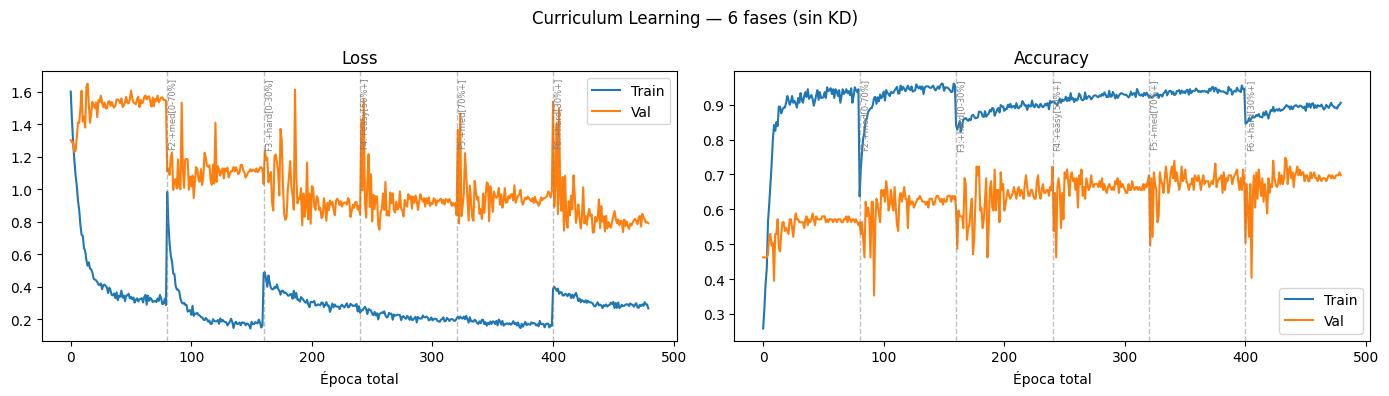

In [8]:
def cat(key, hists):
    return [v for h in hists for v in h.history[key]]

phase_labels = ['F1:easy[0-50%]', 'F2:+med[0-70%]', 'F3:+hard[0-30%]',
                'F4:+easy[50%+]',  'F5:+med[70%+]',  'F6:+hard[30%+]']
boundaries   = list(np.cumsum([len(h.history['loss']) for h in histories[:-1]]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
for ax, key, title in [(ax1, 'loss', 'Loss'), (ax2, 'accuracy', 'Accuracy')]:
    ax.plot(cat(key, histories),          label='Train')
    ax.plot(cat(f'val_{key}', histories), label='Val')
    for b, label in zip(boundaries, phase_labels[1:]):
        ax.axvline(b, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(b + 0.3, ax.get_ylim()[1] * 0.98, label,
                fontsize=6, rotation=90, va='top', color='gray')
    ax.set_title(title); ax.set_xlabel('Época total'); ax.legend()
plt.suptitle('Curriculum Learning — 6 fases (sin KD)')
plt.tight_layout(); plt.show()

## 7. Benchmarking

In [9]:
model.load_weights('curriculum_best.weights.h5')
print('Mejor modelo cargado\n')

print('=== Accuracy por dificultad ===')
for name, ds, y_d in [
    ('easy',   easy_test_ds,  y_easy_test),
    ('medium', med_test_ds,   y_med_test),
    ('hard',   hard_test_ds,  y_hard_test),
    ('other',  other_test_ds, y_other_test),
    ('TOTAL',  test_ds,       y_test),
]:
    _, acc = model.evaluate(ds, verbose=0)
    print(f'  {name:<8} {acc*100:>5.1f}%  {"█" * int(acc * 20)}  (n={len(y_d)})')

Mejor modelo cargado

=== Accuracy por dificultad ===
  easy      94.7%  ██████████████████  (n=19)
  medium    91.3%  ██████████████████  (n=23)
  hard      58.2%  ███████████  (n=79)
  other     36.1%  ███████  (n=83)
  TOTAL     56.4%  ███████████  (n=204)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


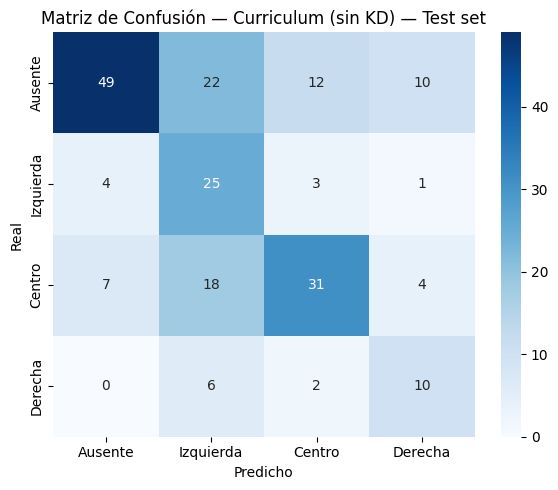

              precision    recall  f1-score   support

     Ausente       0.82      0.53      0.64        93
   Izquierda       0.35      0.76      0.48        33
      Centro       0.65      0.52      0.57        60
     Derecha       0.40      0.56      0.47        18

    accuracy                           0.56       204
   macro avg       0.55      0.59      0.54       204
weighted avg       0.65      0.56      0.58       204



In [10]:
y_pred = np.argmax(model.predict(test_ds), axis=1)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Curriculum (sin KD) — Test set')
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

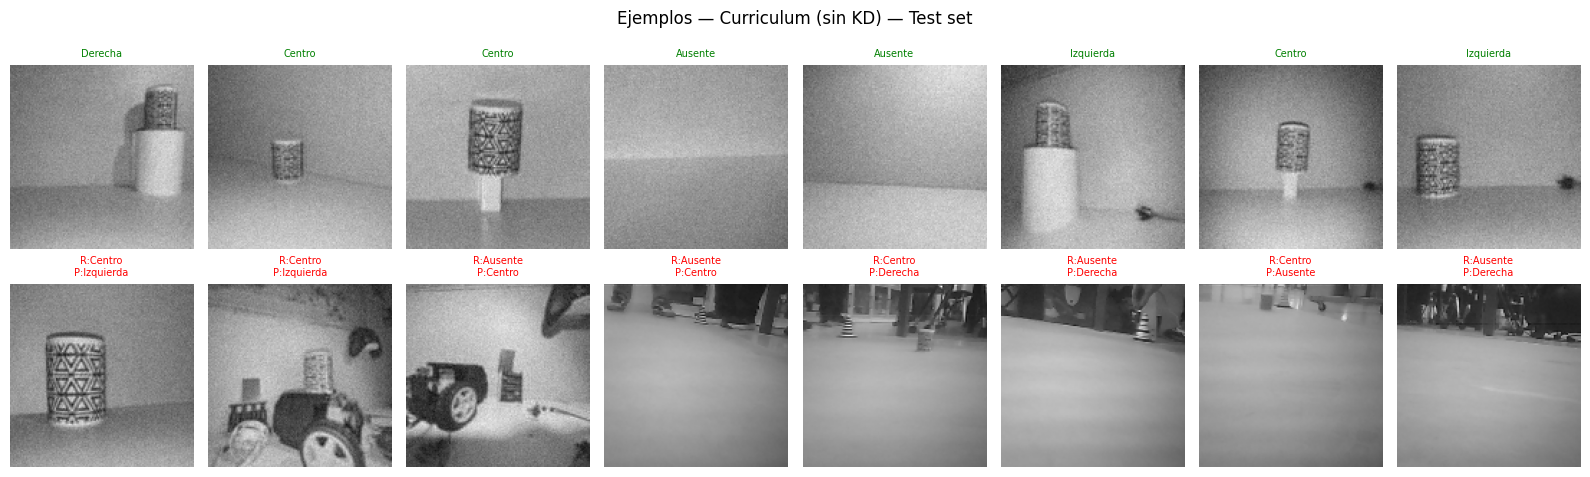

In [11]:
n_show = 8
correct_idx   = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

fig, axes = plt.subplots(2, n_show, figsize=(16, 5))
for row, (idxs, row_label, color) in enumerate([
    (correct_idx,   'Correctas',   'green'),
    (incorrect_idx, 'Incorrectas', 'red'),
]):
    for col in range(n_show):
        ax = axes[row, col]
        if col < len(idxs):
            idx = idxs[col]
            ax.imshow(X_test[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
            real = CLASS_NAMES[y_test[idx]]
            pred = CLASS_NAMES[y_pred[idx]]
            title = real if row == 0 else f'R:{real}\nP:{pred}'
            ax.set_title(title, fontsize=7, color=color)
        ax.axis('off')
    axes[row, 0].set_ylabel(row_label, fontsize=9)
plt.suptitle('Ejemplos — Curriculum (sin KD) — Test set')
plt.tight_layout(); plt.show()

## 8. Conversión a TFLite INT8

In [ ]:
def representative_dataset_gen():
    for i in range(0, min(200, len(cum6_X)), BATCH_SIZE):
        yield [cum6_X[i : i + BATCH_SIZE].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
Path('models/curriculum_int8.tflite').write_bytes(tflite_model)
print(f'TFLite guardado: {len(tflite_model)/1024:.1f} KB')

INFO:tensorflow:Assets written to: /tmp/tmpd851c9aj/assets


INFO:tensorflow:Assets written to: /tmp/tmpd851c9aj/assets


Saved artifact at '/tmp/tmpd851c9aj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137255727393360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137255727393552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137255727396048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137255727395280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137255727394512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137255727394896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137255727396624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137255727395088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137255727395664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137255727396432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13725572739624

/home/raisrb/uandes/sistemas-embebidos/Rep_SE_202601_grupo_Rodriguez_Guzman_Molfino/Lab_3/Extra_1/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1780367295.359286  524460 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1780367295.359632  524460 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1780367295.362950  524460 reader.cc:83] Reading SavedModel from: /tmp/tmpd851c9aj
I0000 00:00:1780367295.363626  524460 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1780367295.363633  524460 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpd851c9aj
I0000 00:00:1780367295.372459  524460 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1780367295.374009  524460 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00

TFLite guardado: 22.8 KB


W0000 00:00:1780367295.757465  524460 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [13]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_det  = interpreter.get_input_details()[0]
output_det = interpreter.get_output_details()[0]
scale, zero_point = input_det['quantization']

y_tflite = []
for img in X_test:
    img_q = (img / scale + zero_point).astype(np.int8)
    interpreter.set_tensor(input_det['index'], img_q[np.newaxis])
    interpreter.invoke()
    y_tflite.append(np.argmax(interpreter.get_tensor(output_det['index'])))
y_tflite = np.array(y_tflite)

acc_tflite = np.mean(y_tflite == y_test)
print(f'Curriculum TFLite INT8 accuracy en test: {acc_tflite * 100:.1f}%')

print('\n{:<28} {:>10} {:>12}'.format('Modelo', 'Accuracy', 'Tamaño'))
print('-' * 53)
for name, acc, size_b in [
    ('Curriculum (float32)', float(np.mean(y_pred == y_test)), model.count_params() * 4),
    ('Curriculum TFLite INT8', acc_tflite, len(tflite_model)),
]:
    print('{:<28} {:>9.1f}%  {:>8.1f} KB'.format(name, acc * 100, size_b / 1024))

Curriculum TFLite INT8 accuracy en test: 55.4%

Modelo                         Accuracy       Tamaño
-----------------------------------------------------
Curriculum (float32)              56.4%      38.5 KB
Curriculum TFLite INT8            55.4%      22.8 KB


/home/raisrb/uandes/sistemas-embebidos/Rep_SE_202601_grupo_Rodriguez_Guzman_Molfino/Lab_3/Extra_1/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 9. Guardar modelo

In [16]:
model.save('models/curriculum_final.keras')
print('Guardados:')
print('  curriculum_final.keras   — Modelo float32')
print('  curriculum_int8.tflite   — Listo para ESP32-CAM')
print(f'  Params: {model.count_params():,}')

Guardados:
  curriculum_final.keras   — Modelo float32
  curriculum_int8.tflite   — Listo para ESP32-CAM
  Params: 9,860
